# Week 05: Classification

## Introduction

In this notebook, we apply the ideas from this week's lesson on binary classification by building a logistic regression model to predict whether a credit card holder will default in the next month, using the Credit Card Default dataset from the UCI Machine Learning Repository.

Along the way, we will:

* Explore the dataset and examine the class distribution.
* Build a preprocessing and logistic regression pipeline.
* Evaluate classification performance using accuracy, precision, recall, F1 score, and ROC AUC.
* Interpret confusion matrices and the ROC curve in terms of true positives, false positives, true negatives, and false negatives.
* Investigate how changing the classification threshold changes the tradeoff between recall and false positives.
* Define a **business objective:** achieve a required level of recall while minimizing unnecessary interventions caused by false positives.
* Use the **validation set** to select a classification threshold that best meets the business objective.
* Refit the selected model on the full **development set** and evaluate it once on the **test set**.
* Examine why performance on unseen test data may differ from validation performance, even when the model-selection procedure is sound.

By the end of this notebook, you should understand that evaluating a classifier involves more than choosing a model or reporting its accuracy. Classification requires deciding **which errors matter most**, selecting a decision threshold that reflects the business objective, and using validation and test data appropriately so that the final evaluation provides an honest estimate of performance on unseen data.


In [1]:
# Required imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Modules
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
)



## Load and Explore the Dataset

In [2]:
# --------------------------------------------------
# Load the Credit Card Default Dataset
# --------------------------------------------------

# Install once if necessary:
# !pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd

# UCI dataset ID 350:
# Default of Credit Card Clients
credit_data = fetch_ucirepo(id=350)

# Predictor variables
X = credit_data.data.features.copy()

# Rename predictors (these are more readable versions of the original names)
X.columns = [
    "credit_limit",
    "gender",
    "education",
    "marital_status",
    "age",
    "repay_status_sep",
    "repay_status_aug",
    "repay_status_jul",
    "repay_status_jun",
    "repay_status_may",
    "repay_status_apr",
    "bill_amt_sep",
    "bill_amt_aug",
    "bill_amt_jul",
    "bill_amt_jun",
    "bill_amt_may",
    "bill_amt_apr",
    "payment_amt_sep",
    "payment_amt_aug",
    "payment_amt_jul",
    "payment_amt_jun",
    "payment_amt_may",
    "payment_amt_apr"
]


# Binary target:
# 1 = defaulted the following month
# 0 = did not default
y = credit_data.data.targets.squeeze().copy()

# Give the target a simpler name
y.name = "default"

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.value_counts())
print()
display(y.value_counts(normalize=True).round(4))

X shape: (30000, 23)
y shape: (30000,)


,credit_limit,gender,education,marital_status,age,repay_status_sep,repay_status_aug,repay_status_jul,repay_status_jun,repay_status_may,...,bill_amt_jul,bill_amt_jun,bill_amt_may,bill_amt_apr,payment_amt_sep,payment_amt_aug,payment_amt_jul,payment_amt_jun,payment_amt_may,payment_amt_apr
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


default
0    23364
1     6636
Name: count, dtype: int64

default
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [3]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   credit_limit      30000 non-null  int64
 1   gender            30000 non-null  int64
 2   education         30000 non-null  int64
 3   marital_status    30000 non-null  int64
 4   age               30000 non-null  int64
 5   repay_status_sep  30000 non-null  int64
 6   repay_status_aug  30000 non-null  int64
 7   repay_status_jul  30000 non-null  int64
 8   repay_status_jun  30000 non-null  int64
 9   repay_status_may  30000 non-null  int64
 10  repay_status_apr  30000 non-null  int64
 11  bill_amt_sep      30000 non-null  int64
 12  bill_amt_aug      30000 non-null  int64
 13  bill_amt_jul      30000 non-null  int64
 14  bill_amt_jun      30000 non-null  int64
 15  bill_amt_may      30000 non-null  int64
 16  bill_amt_apr      30000 non-null  int64
 17  payment_amt_sep   30000 non-nul

### Dataset Info and Statistics

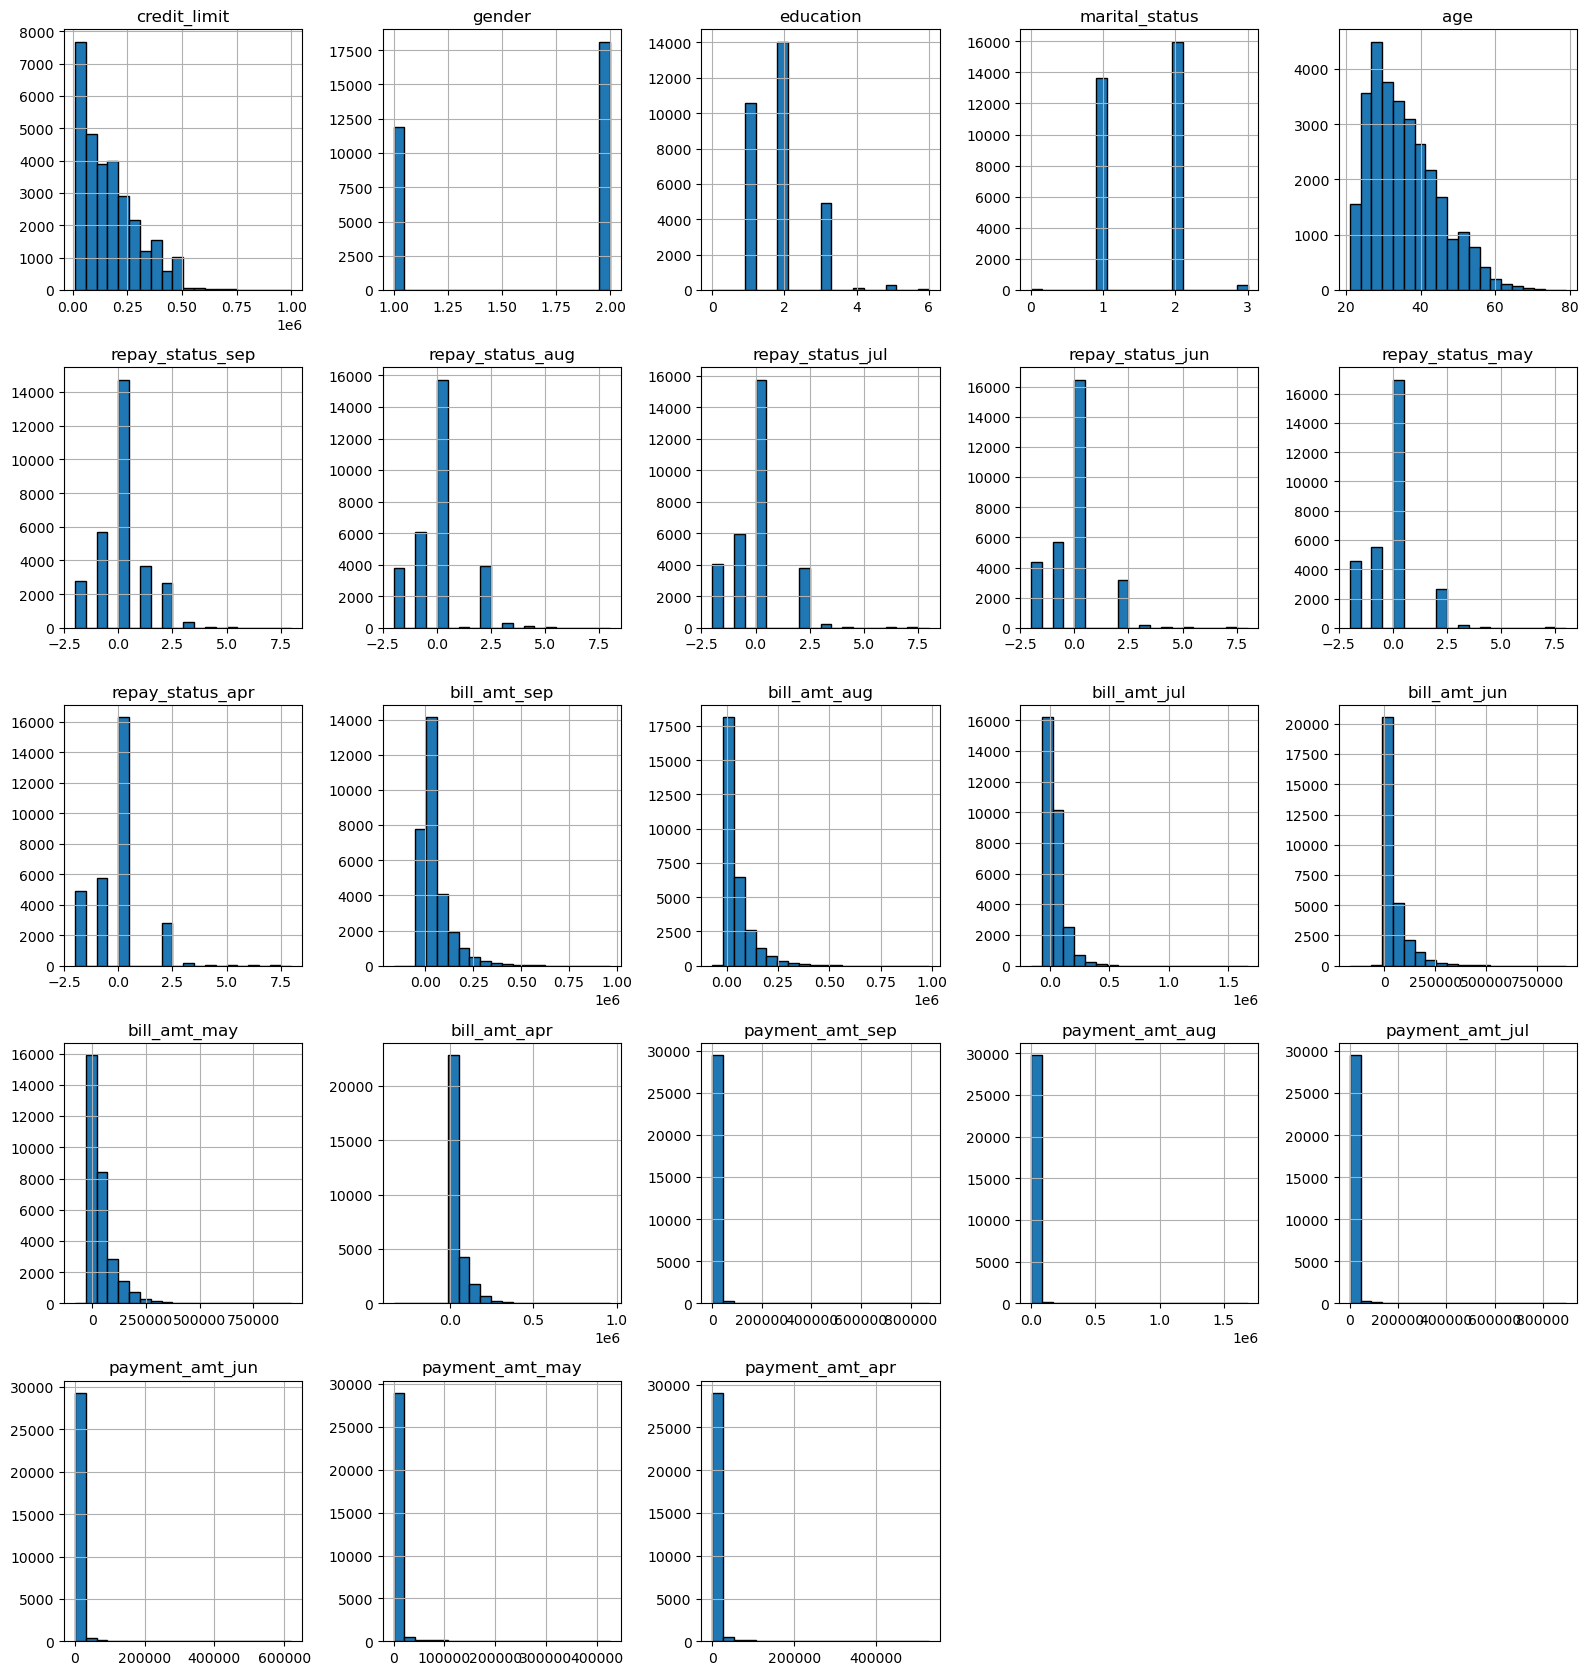

In [4]:
X.hist(
    bins=20,
    figsize=(16, 20),
    layout=(6, 5),
    edgecolor="black"
)

plt.tight_layout()
plt.show()

### Is the dataset balanced?

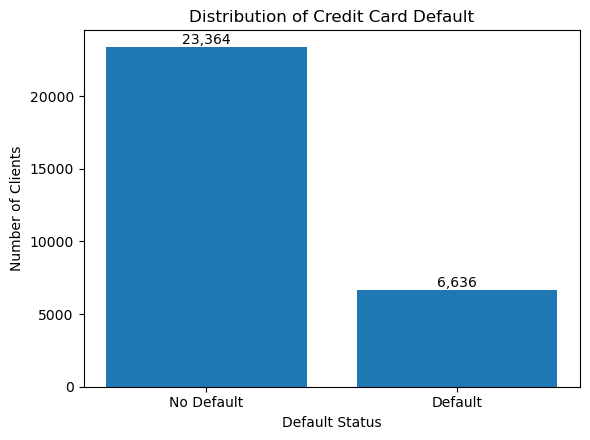

In [5]:
# --------------------------------------------------
# Distribution of the Target Variable
# --------------------------------------------------

import matplotlib.pyplot as plt

class_counts = y.value_counts().sort_index()

plt.figure(figsize=(6, 4.5))

plt.bar(
    ["No Default", "Default"],
    class_counts.values
)

plt.title("Distribution of Credit Card Default")
plt.xlabel("Default Status")
plt.ylabel("Number of Clients")

# Add counts above the bars
for i, count in enumerate(class_counts.values):
    plt.text(
        i,
        count,
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

**The target variable is moderately imbalanced:** most clients did not default, while a smaller but still substantial proportion did. We will initially fit logistic regression without rebalancing and evaluate performance using class-specific metrics such as precision, recall, and F1 score. Because failing to identify a client who will default may be more costly than incorrectly flagging a client who would repay, we will later examine whether lowering the decision threshold improves sensitivity to defaults. 

> Class weighting is another possible strategy for handling class imbalance, but here we will focus on adjusting the decision threshold.

#### Split the Data

In [6]:
# --------------------------------------------------
# Train / Validation / Test Split
# --------------------------------------------------

from sklearn.model_selection import train_test_split

# First set aside 10% for the final test set
X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    stratify=y,
    random_state=42
)

# Split the remaining 90% into:
# 80% training and 10% validation overall
X_train, X_validation, y_train, y_validation = train_test_split(
    X_development,
    y_development,
    test_size=1/9,
    stratify=y_development,
    random_state=42
)

X_train.shape,y_train.shape,X_validation.shape,y_validation.shape, X_test.shape,y_test.shape

((24000, 23), (24000,), (3000, 23), (3000,), (3000, 23), (3000,))

#### Create and fit the pipeline

> Feature scaling puts numerical predictors on comparable scales. This is important for logistic regression because its coefficients are estimated through numerical optimization. When some features have much larger ranges than others, the optimization can proceed inefficiently and may have difficulty converging. Standardization transforms each feature to have approximately mean 0 and standard deviation 1, making the fitting process more stable and efficient.

Scaling should be fitted only on the training data, so we include `StandardScaler()` inside the pipeline.

In [7]:
# --------------------------------------------------
# Logistic Regression Pipeline
# --------------------------------------------------

logistic_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000,
                       class_weight=None,           
         #              class_weight="balanced"        # if we want to rebalance during training
                      )
)

# Fit the scaler and model using only the training data
logistic_pipeline.fit(X_train, y_train);

Logistic Regression: Validation Results (Threshold = 0.5)
---------------------------------------
              precision    recall  f1-score   support

  No Default     0.8173    0.9692    0.8868      2336
     Default     0.6870    0.2380    0.3535       664

    accuracy                         0.8073      3000
   macro avg     0.7521    0.6036    0.6201      3000
weighted avg     0.7885    0.8073    0.7688      3000

Accuracy       : 0.8073
Precision      : 0.6870
Default Recall : 0.2380
F1 Score       : 0.3535
ROC AUC        : 0.7301





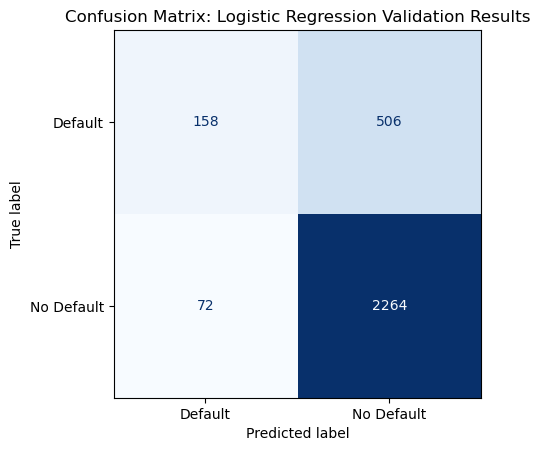

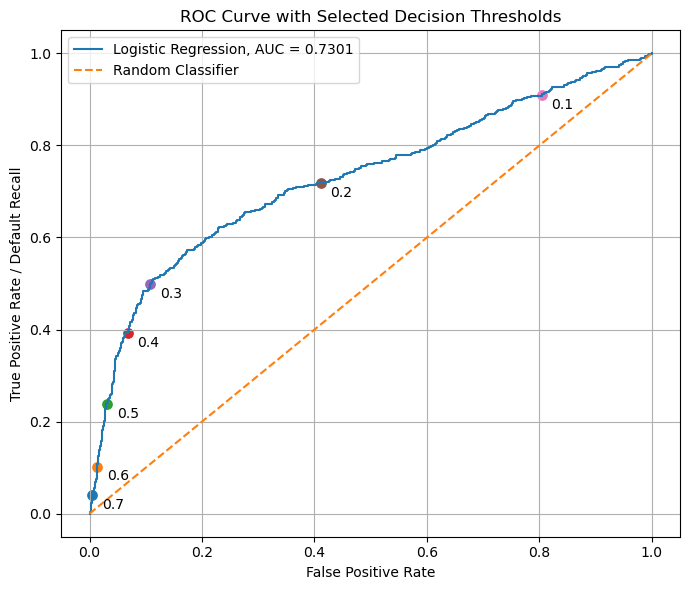

Baseline Comparison
-------------------
Majority class                : No Default
Baseline validation accuracy  : 0.7787
Logistic regression accuracy  : 0.8073
Improvement over baseline     : 0.0287


In [8]:
# --------------------------------------------------
# Logistic Regression: Validation Results
# --------------------------------------------------

# Class predictions on the validation set
y_pred = logistic_pipeline.predict(X_validation)

# Predicted probabilities for the positive class:
# 1 = default
y_prob = logistic_pipeline.predict_proba(X_validation)[:, 1]


# --------------------------------------------------
# Classification Metrics
# --------------------------------------------------

print("Logistic Regression: Validation Results (Threshold = 0.5)")
print("---------------------------------------")

print(
    classification_report(
        y_validation,
        y_pred,
        labels=[0, 1],
        target_names=["No Default", "Default"],
        digits=4
    )
)

accuracy = accuracy_score(y_validation, y_pred)

# Metrics for the positive class: Default = 1
precision = precision_score(y_validation, y_pred, pos_label=1)
sensitivity = recall_score(y_validation, y_pred, pos_label=1)
f1 = f1_score(y_validation, y_pred, pos_label=1)

auc = roc_auc_score(y_validation, y_prob)

print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Default Recall : {sensitivity:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"ROC AUC        : {auc:.4f}")
print("\n\n")


# --------------------------------------------------
# Confusion Matrix
# --------------------------------------------------

# Put the positive class (Default = 1) first
cm = confusion_matrix(
    y_validation,
    y_pred,
    labels=[1, 0]
)

fig, ax = plt.subplots(figsize=(5, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Default", "No Default"]
)

disp.plot(
    cmap="Blues",
    colorbar=False,
    values_format="d",
    ax=ax
)

ax.set_title(
    "Confusion Matrix: Logistic Regression Validation Results"
)

plt.tight_layout()
plt.show()

print("\n\n")


# --------------------------------------------------
# ROC Curve with Selected Decision Thresholds
# --------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_validation,
    y_prob,
    pos_label=1
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression, AUC = {auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

# Thresholds to label on the ROC curve
thresholds_to_label = [0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]

for target_threshold in thresholds_to_label:

    # Find the ROC point whose threshold is closest
    # to the desired threshold
    index = np.argmin(
        np.abs(thresholds - target_threshold)
    )

    plt.scatter(
        fpr[index],
        tpr[index],
        s=45
    )

    plt.annotate(
        f"{thresholds[index]:.1f}",
        xy=(fpr[index], tpr[index]),
        xytext=(7, -10),
        textcoords="offset points"
    )

plt.title("ROC Curve with Selected Decision Thresholds")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Default Recall")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Accuracy Baseline
# --------------------------------------------------

# Determine the majority class using only the training data
majority_class = y_train.value_counts().idxmax()

# Predict the training-set majority class for every validation sample
baseline_predictions = np.full(
    shape=len(y_validation),
    fill_value=majority_class
)

# Evaluate the baseline on the validation set
baseline_accuracy = accuracy_score(
    y_validation,
    baseline_predictions
)

majority_class_name = (
    "Default" if majority_class == 1 else "No Default"
)

print("Baseline Comparison")
print("-------------------")
print(f"Majority class                : {majority_class_name}")
print(f"Baseline validation accuracy  : {baseline_accuracy:.4f}")
print(f"Logistic regression accuracy  : {accuracy:.4f}")
print(f"Improvement over baseline     : {accuracy - baseline_accuracy:.4f}")

## Business Objective and Three-Step Threshold-Tuning Workflow

The purpose of the model is to **identify customers who are at risk of default and may benefit from early intervention**. The lender could use these predictions to prioritize actions such as payment reminders, account reviews, or offers of revised payment arrangements.

Two classification metrics are especially important.

**Default recall/sensitivity**

> Of all customers who actually defaulted, what proportion did the model identify in advance?

High default recall means that relatively few future defaults are missed. A customer who actually defaults but is not identified by the model is a **false negative**.

**Default precision**

> Of all customers the model flagged as likely to default, what proportion actually defaulted?

High default precision means that the intervention program is focused on customers who are genuinely at risk. A customer who is flagged but does not default is a **false positive**.

These metrics reflect different business concerns. 
- Missing a future default may lead to credit losses and collection costs, but
- Unnecessarily contacting a low-risk customer may create administrative expense and customer annoyance.
 
Lowering the decision threshold generally increases default recall, but it also produces more false positives and therefore lowers precision.

#### Business Selection Rule

We will use the validation set to choose a decision threshold according to the following requirement:

> **The model must identify at least 70% of customers who default. Among all thresholds that meet this recall requirement, we will select the threshold with the highest precision.**

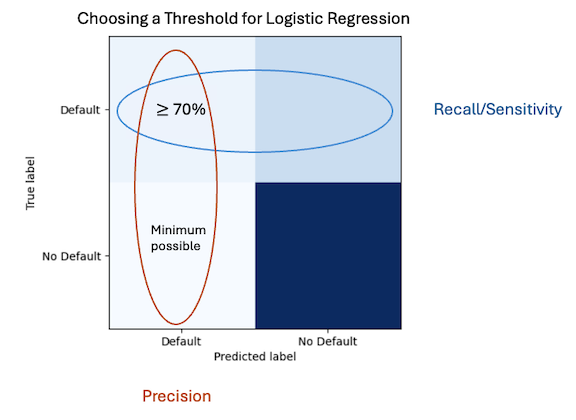

> **Warning:** The 70% recall requirement is enforced on the validation set. After the threshold is selected, it is fixed before evaluating the test set. Because the test set contains different observations, test recall and precision may differ from the validation results; in particular, test recall is not guaranteed to remain at or above 70%.


The threshold selection process therefore has two parts:

1. Eliminate any threshold with default recall below 70%, because it misses too many future defaults.
2. Among the remaining thresholds, select the one with the highest precision, because it directs interventions toward the most relevant customers and minimizes unnecessary contacts.

The final threshold is therefore selected to satisfy a specific business objective rather than accepted automatically as 0.5.

#### Three-Step Tuning Workflow

1. Examine several representative thresholds to see how the numbers of true positives, false positives, true negatives, and false negatives change.
2. Evaluate a wider range of thresholds on the validation set and calculate default recall and default precision for each one.
3. Retain thresholds with default recall of at least 70%, then select the threshold with the highest default precision.

All threshold selection must be performed using the validation set. The full target vector `y` and the test set must **not** be used during tuning.


#### Set the minimum required recall

In [9]:
minimum_recall = 0.70

## 1. Visualize several representative thresholds

This provides the intuitive demonstration: as the threshold decreases, the model predicts more defaults, increasing true positives but also false positives.

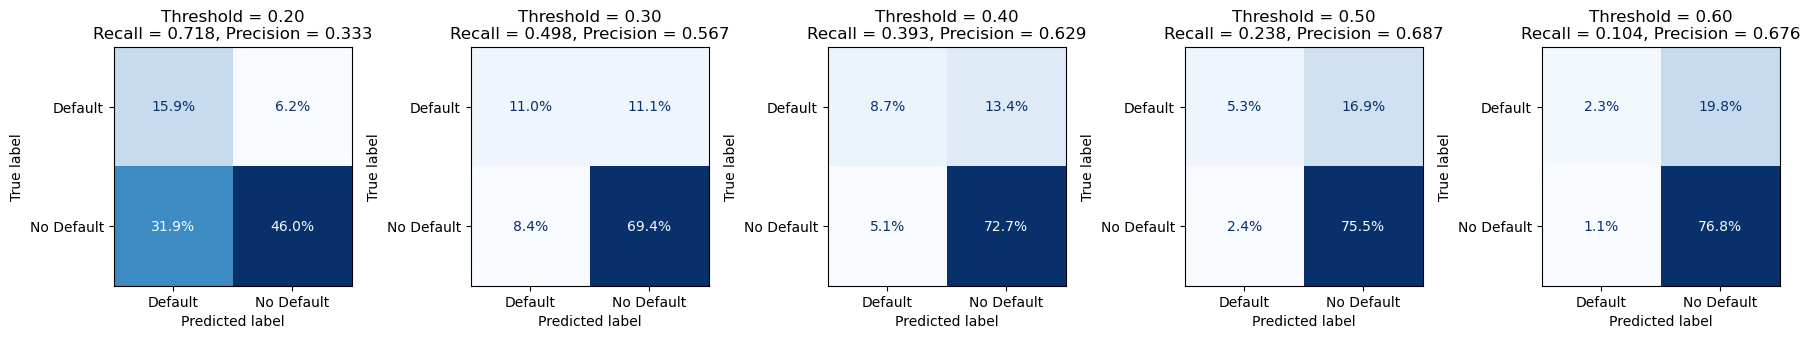

In [16]:
# --------------------------------------------------
# Evaluate Validation Metrics Across Thresholds
# --------------------------------------------------

thresholds = np.arange(0.10, 0.61, 0.01)

results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_validation,
            y_pred_threshold
        ),
        "Precision": precision_score(
            y_validation,
            y_pred_threshold,
            pos_label=1,
            zero_division=0
        ),
        "Default Recall": recall_score(
            y_validation,
            y_pred_threshold,
            pos_label=1
        ),
        "F1 Score": f1_score(
            y_validation,
            y_pred_threshold,
            pos_label=1
        )
    })

threshold_results = pd.DataFrame(results)


# --------------------------------------------------
# Visualize Several Representative Thresholds
# --------------------------------------------------

representative_thresholds = [
    0.20, 0.30, 0.40, 0.50, 0.60
]

fig, axes = plt.subplots(
    1,
    len(representative_thresholds),
    figsize=(18, 4)
)

for ax, threshold in zip(
    axes,
    representative_thresholds
):

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_validation,
        y_pred_threshold,
        labels=[1, 0],
        normalize="all"
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Default", "No Default"]
    )

    disp.plot(
        cmap="Blues",
        colorbar=False,
        values_format=".1%",
        ax=ax
    )

    recall = recall_score(
        y_validation,
        y_pred_threshold,
        pos_label=1
    )

    precision = precision_score(
        y_validation,
        y_pred_threshold,
        pos_label=1,
        zero_division=0
    )

    ax.set_title(
        f"Threshold = {threshold:.2f}\n"
        f"Recall = {recall:.3f}, "
        f"Precision = {precision:.3f}"
    )

plt.tight_layout()
plt.show()

## 2. Evaluate a finer range of thresholds

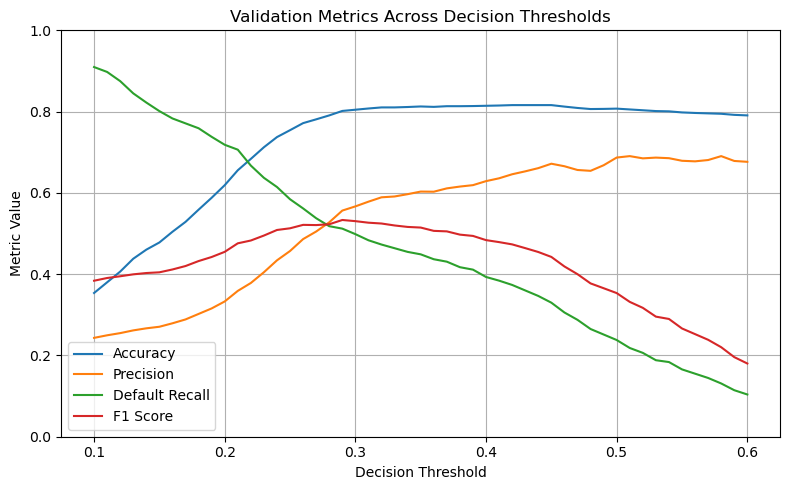

In [17]:
# --------------------------------------------------
# Validation Metrics Across a Range of Thresholds
# --------------------------------------------------


plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Accuracy"],
    label="Accuracy"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Default Recall"],
    label="Default Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    label="F1 Score"
)


plt.title("Validation Metrics Across Decision Thresholds")
plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Apply the business selection rule

In [20]:
# --------------------------------------------------
# Show Thresholds Around 70% Default Recall
# --------------------------------------------------

target_recall = 0.70

# Find the row with recall closest to the target
center_index = (
    threshold_results["Default Recall"] - target_recall
).abs().idxmin()

# Show 5 thresholds below and 5 above
start_index = max(0, center_index - 5)
end_index = min(len(threshold_results), center_index + 6)

threshold_results.iloc[start_index:end_index].round(4)

,Threshold,Accuracy,Precision,Default Recall,F1 Score
6,0.16,0.5043,0.2791,0.7831,0.4116
7,0.17,0.5287,0.2886,0.7711,0.4200
8,0.18,0.5587,0.3022,0.7590,0.4322
9,0.19,0.5880,0.3157,0.7380,0.4422
10,0.20,0.6190,0.3329,0.7184,0.4549
11,0.21,0.6557,0.3588,0.7063,0.4759
12,0.22,0.6837,0.3783,0.6672,0.4828
13,0.23,0.7123,0.4048,0.6370,0.4950
14,0.24,0.7373,0.4340,0.6145,0.5087
15,0.25,0.7543,0.4570,0.5843,0.5129


In [18]:
# --------------------------------------------------
# Select a Threshold Using the Business Requirement
# --------------------------------------------------


# Keep only thresholds that identify at least
# minimum_recall of the clients who default
eligible_thresholds = threshold_results[
    threshold_results["Default Recall"] >= minimum_recall
].copy()

# Among eligible thresholds, select the one
# with the highest precision
best_row = eligible_thresholds.loc[
    eligible_thresholds["Precision"].idxmax()
]

selected_threshold = best_row["Threshold"]

print("Threshold Selection")
print("-------------------")
print(f"Minimum required default recall: {minimum_recall:.2f}")
print(f"Selected threshold             : {selected_threshold:.3f}")
print(f"Validation accuracy            : {best_row['Accuracy']:.4f}")
print(f"Validation precision           : {best_row['Precision']:.4f}")
print(f"Validation default recall      : {best_row['Default Recall']:.4f}")
print(f"Validation F1 score            : {best_row['F1 Score']:.4f}")

Threshold Selection
-------------------
Minimum required default recall: 0.70
Selected threshold             : 0.210
Validation accuracy            : 0.6557
Validation precision           : 0.3588
Validation default recall      : 0.7063
Validation F1 score            : 0.4759


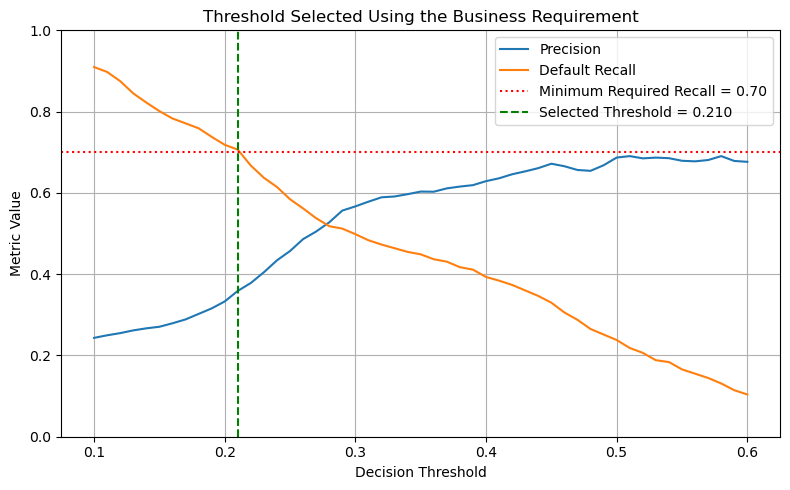

In [19]:
# --------------------------------------------------
# Plot the Selected Threshold
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Default Recall"],
    label="Default Recall"
)

plt.axhline(
    minimum_recall,
    linestyle=":",
    color='r',
    label=f"Minimum Required Recall = {minimum_recall:.2f}"
)

plt.axvline(
    selected_threshold,
    linestyle="--",
    color='g',
    label=f"Selected Threshold = {selected_threshold:.3f}"
)

plt.title("Threshold Selected Using the Business Requirement")
plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Because recall generally increases as the threshold decreases, the selected threshold will probably be near the **highest threshold that still achieves 70% recall**. That tends to maximize precision while satisfying the recall constraint.

#### Evaluate the selected threshold visually

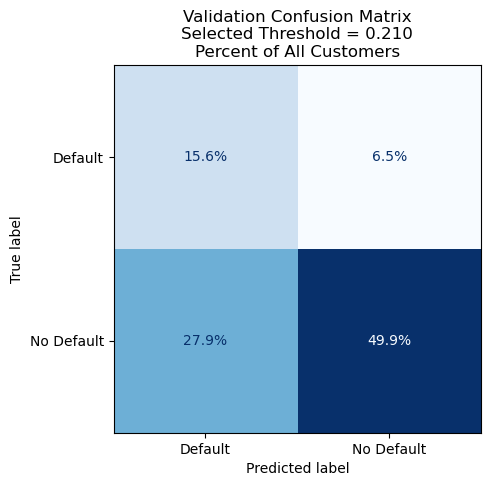

In [21]:
# --------------------------------------------------
# Confusion Matrix as Percentages of All Customers
# --------------------------------------------------


y_pred_selected = (
    y_prob >= selected_threshold
).astype(int)

cm_percent = confusion_matrix(
    y_validation,
    y_pred_selected,
    labels=[1, 0],
    normalize="all"
)

fig, ax = plt.subplots(figsize=(5, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent,
    display_labels=["Default", "No Default"]
)

disp.plot(
    cmap="Blues",
    colorbar=False,
    values_format=".1%",
    ax=ax
)

ax.set_title(
    "Validation Confusion Matrix\n"
    f"Selected Threshold = {selected_threshold:.3f}\n"
    "Percent of All Customers"
)

plt.tight_layout()
plt.show()

In [22]:
print(f"Default Recall: {468 / (468 + 196):.4f}")
print(f"Default Precision: {468 / (468 + 828):.4f}")

Default Recall: 0.7048
Default Precision: 0.3611


Final Logistic Regression Test Results
--------------------------------------
Selected threshold : 0.210
Accuracy           : 0.6370
Default precision  : 0.3339
Default recall     : 0.6431
F1 score           : 0.4395
ROC AUC            : 0.7037


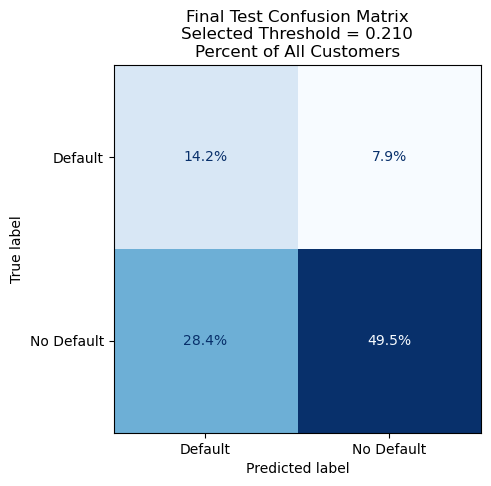

In [23]:
# --------------------------------------------------
# Final Evaluation on the Test Set
# --------------------------------------------------


# --------------------------------------------------
# Refit the selected model on the full development set
# --------------------------------------------------

# Model choice, preprocessing, and decision threshold
# have already been selected using the training/validation data.
# Now refit the pipeline using all development data
# (training + validation) before evaluating on the test set.
logistic_pipeline.fit(X_development, y_development)


# --------------------------------------------------
# Predictions on the untouched test set
# --------------------------------------------------

# Predicted probabilities for the positive class: Default = 1
y_prob_test = logistic_pipeline.predict_proba(X_test)[:, 1]

# Apply the threshold selected using the validation set
y_pred_test = (
    y_prob_test >= selected_threshold
).astype(int)


# --------------------------------------------------
# Final Test Metrics
# --------------------------------------------------

test_accuracy = accuracy_score(y_test, y_pred_test)

test_precision = precision_score(
    y_test,
    y_pred_test,
    pos_label=1,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_pred_test,
    pos_label=1
)

test_f1 = f1_score(
    y_test,
    y_pred_test,
    pos_label=1
)

test_auc = roc_auc_score(y_test, y_prob_test)

print("Final Logistic Regression Test Results")
print("--------------------------------------")
print(f"Selected threshold : {selected_threshold:.3f}")
print(f"Accuracy           : {test_accuracy:.4f}")
print(f"Default precision  : {test_precision:.4f}")
print(f"Default recall     : {test_recall:.4f}")
print(f"F1 score           : {test_f1:.4f}")
print(f"ROC AUC            : {test_auc:.4f}")


# --------------------------------------------------
# Test Confusion Matrix: Percent of All Customers
# --------------------------------------------------

cm_test_percent = confusion_matrix(
    y_test,
    y_pred_test,
    labels=[1, 0],
    normalize="all"
)

fig, ax = plt.subplots(figsize=(5, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_percent,
    display_labels=["Default", "No Default"]
)

disp.plot(
    cmap="Blues",
    colorbar=False,
    values_format=".1%",
    ax=ax
)

ax.set_title(
    "Final Test Confusion Matrix\n"
    f"Selected Threshold = {selected_threshold:.3f}\n"
    "Percent of All Customers"
)

plt.tight_layout()
plt.show()

> **Note:** In practice, a decision threshold selected on validation data cannot guarantee a particular level of recall on future data. Even if the validation set achieves the business target, performance may be higher or lower on the test set or in production because of sampling variability and changes in the data. If achieving at least 70% recall is important, a sensible strategy is therefore to build in a margin by targeting somewhat higher recall during model development, use reliable validation methods to estimate how well the model is likely to generalize, and then evaluate the final model and threshold on untouched test data. The remaining uncertainty cannot be eliminated; it must be recognized as part of applying machine learning to new data.

In [24]:
# --------------------------------------------------
# Tier Summary Table on the Test Set
# --------------------------------------------------


# --------------------------------------------------
# Fixed intervention thresholds
# --------------------------------------------------

# Entry into the intervention program was selected
# using the validation set.
no_intervention_threshold = selected_threshold

# These higher-intensity thresholds are illustrative.
moderate_threshold = 0.35
high_threshold = 0.55


# --------------------------------------------------
# Assign each test customer to one intervention tier
# --------------------------------------------------

tier_labels = [
    "No Intervention",
    "Low Intervention",
    "Moderate Intervention",
    "High Intervention"
]

test_tiers = pd.cut(
    y_prob_test,
    bins=[
        -np.inf,
        no_intervention_threshold,
        moderate_threshold,
        high_threshold,
        np.inf
    ],
    labels=tier_labels,
    right=False
)


# --------------------------------------------------
# Combine predictions and actual outcomes
# --------------------------------------------------

tier_results = pd.DataFrame({
    "Intervention Tier": test_tiers,
    "Predicted Probability": y_prob_test,
    "Actual Default": y_test.to_numpy()
})


# --------------------------------------------------
# Summarize each tier
# --------------------------------------------------

tier_summary = (
    tier_results
    .groupby(
        "Intervention Tier",
        observed=False
    )
    .agg(
        Number_of_Customers=("Actual Default", "size"),
        Actual_Defaults=("Actual Default", "sum"),
        Average_Predicted_Probability=(
            "Predicted Probability",
            "mean"
        ),
        Actual_Default_Rate=("Actual Default", "mean")
    )
    .reset_index()
)


# Percentage of all test customers assigned to each tier
tier_summary["Percent_of_Customers"] = (
    tier_summary["Number_of_Customers"] /
    len(tier_results)
)


# Percentage of all actual defaults captured by each tier
total_defaults = tier_results["Actual Default"].sum()

tier_summary["Percent_of_All_Defaults"] = (
    tier_summary["Actual_Defaults"] /
    total_defaults
)


# --------------------------------------------------
# Reorder columns
# --------------------------------------------------

tier_summary = tier_summary[
    [
        "Intervention Tier",
        "Number_of_Customers",
        "Percent_of_Customers",
        "Average_Predicted_Probability",
        "Actual_Defaults",
        "Actual_Default_Rate",
        "Percent_of_All_Defaults"
    ]
]


# --------------------------------------------------
# Format a copy for display
# --------------------------------------------------

tier_summary_display = tier_summary.copy()

for column in [
    "Percent_of_Customers",
    "Average_Predicted_Probability",
    "Actual_Default_Rate",
    "Percent_of_All_Defaults"
]:
    tier_summary_display[column] = (
        tier_summary_display[column]
        .map(lambda value: f"{value:.1%}")
    )

tier_summary_display.columns = [
    "Intervention Tier",
    "Customers",
    "Percent of Customers",
    "Average Predicted Probability",
    "Actual Defaults",
    "Actual Default Rate",
    "Percent of All Defaults"
]

print("Test-Set Intervention Tier Summary")
print("----------------------------------")
print(tier_summary_display.to_string(index=False))

Test-Set Intervention Tier Summary
----------------------------------
    Intervention Tier  Customers Percent of Customers Average Predicted Probability  Actual Defaults Actual Default Rate Percent of All Defaults
      No Intervention       1721                57.4%                         12.5%              237               13.8%                   35.7%
     Low Intervention        847                28.2%                         25.2%              165               19.5%                   24.8%
Moderate Intervention        258                 8.6%                         44.4%              135               52.3%                   20.3%
    High Intervention        174                 5.8%                         65.8%              127               73.0%                   19.1%


## Business Outcomes for the Default Intervention Program

* **50.3% of customers are correctly predicted not to default** and would receive no intervention.
* **15.6% are correctly identified as likely to default** and could receive a useful early intervention.
* **27.6% are incorrectly flagged as likely to default** and could receive an unnecessary intervention.
* **6.5% are incorrectly predicted not to default** and would be missed by the intervention program.

**Note:** The predicted probabilities could also be used to determine the intensity of the intervention. Among the **43.2% of customers predicted to default**, customers with relatively low predicted probabilities might receive a simple automated reminder, while those with higher predicted probabilities might receive progressively more substantial interventions, such as personal outreach, account review, or an offer of alternative payment arrangements.

Such an analysis might begin with a **rank plot**, which orders customers by their predicted probability of default. The lender could then define probability cutoffs for different levels of intervention, based on operational capacity, intervention costs, and the consequences of missed defaults.


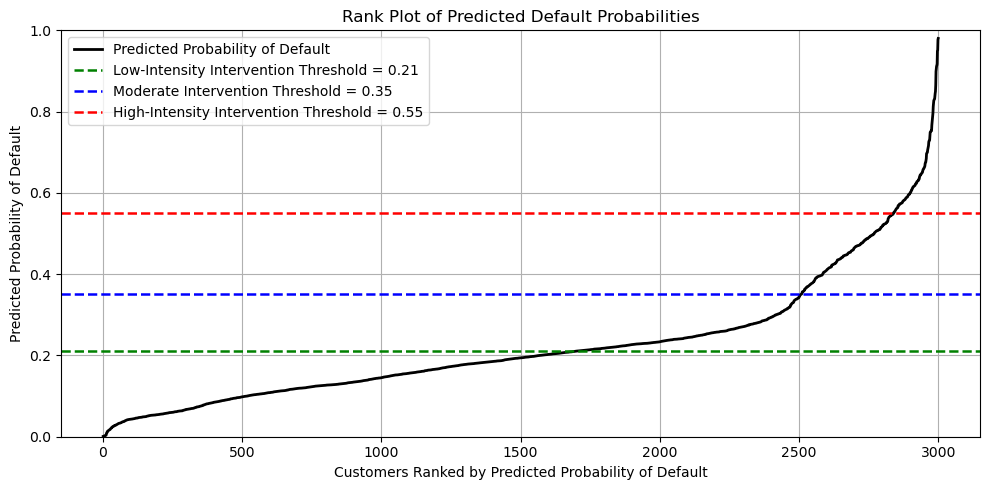

In [25]:
# --------------------------------------------------
# Rank Plot with Colored Intervention Threshold Lines
# --------------------------------------------------

# Put validation results into a DataFrame
rank_df = pd.DataFrame({
    "Actual Default": y_validation.to_numpy(),
    "Predicted Probability": y_prob
})

# Sort customers from lowest to highest predicted probability
rank_df = rank_df.sort_values(
    by="Predicted Probability"
).reset_index(drop=True)

# Create a rank index
rank_df["Customer Rank"] = np.arange(1, len(rank_df) + 1)

# Illustrative intervention thresholds
low_intervention = selected_threshold   # entry into intervention program
moderate_intervention = 0.35
high_intervention = 0.55

plt.figure(figsize=(10, 5))

# Rank curve
plt.plot(
    rank_df["Customer Rank"],
    rank_df["Predicted Probability"],
    linewidth=2,
    color="black",
    label="Predicted Probability of Default"
)

# Intervention threshold lines
plt.axhline(
    low_intervention,
    color="green",
    linestyle="--",
    linewidth=1.8,
    label=f"Low-Intensity Intervention Threshold = {low_intervention:.2f}"
)

plt.axhline(
    moderate_intervention,
    color="blue",
    linestyle="--",
    linewidth=1.8,
    label=f"Moderate Intervention Threshold = {moderate_intervention:.2f}"
)

plt.axhline(
    high_intervention,
    color="red",
    linestyle="--",
    linewidth=1.8,
    label=f"High-Intensity Intervention Threshold = {high_intervention:.2f}"
)

plt.title("Rank Plot of Predicted Default Probabilities")
plt.xlabel("Customers Ranked by Predicted Probability of Default")
plt.ylabel("Predicted Probability of Default")
plt.ylim(0, 1)
plt.grid(True)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()